# Oscar Demographics Analysis

* This file contains several graphs that highlight gender and race representation in the Oscars from data spanning the past 98 years (all 98 ceremonies!)
* These graphs highlight the sheer dominance that white men have held over the film and entertainment industry from its inception
* Racial diversity seems to have increased exponentially in the 21st century, but the vast majority of winners and nominees are still white
* The proportion of female nominees has been steadily increasing over time, but the proportion of female winners has surprisingly decreased this decade

### Loading the dataset and necessary libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
oscar_nominees = pd.read_csv("../data/oscars_demographics_comprehensive.csv")

## Gender Representation of Nominees Over Time

This graph plots the raw annual nomination counts by gender.

<Figure size 640x480 with 0 Axes>

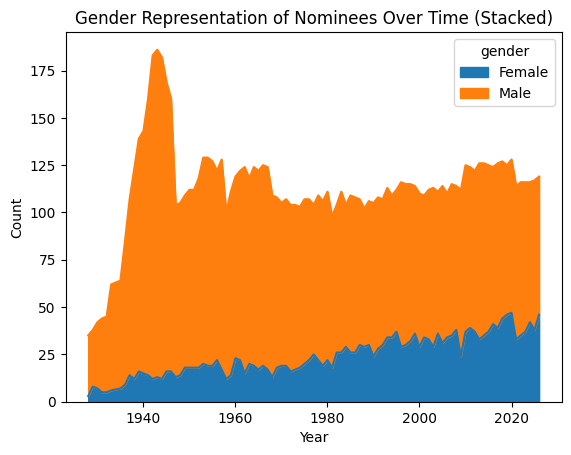

In [3]:
gender_year = oscar_nominees.groupby(['year_ceremony', 'gender']).size().unstack(fill_value=0)

plt.figure()
gender_year.plot.area()
plt.title("Gender Representation of Nominees Over Time (Stacked)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## Female Nominee & Winner Proportion by Decade

This plot tracks the proportion of female nominees and winners across decades.
By comparing the two lines, we can assess whether female representation differs
between nomination and winning stages of the Oscars.

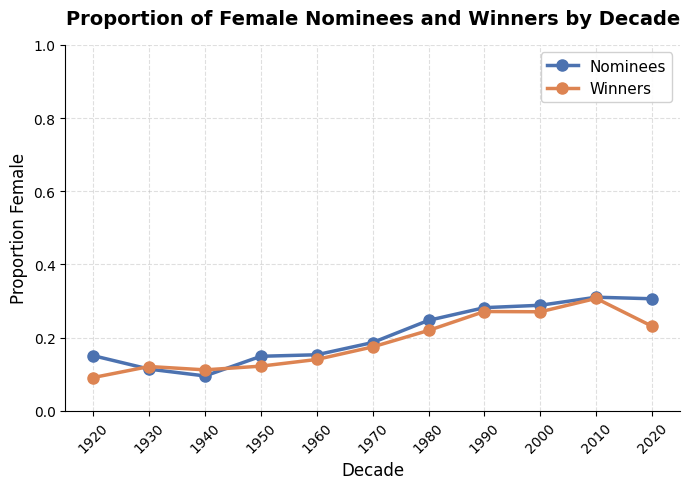

In [17]:
oscar_nominees['decade'] = (oscar_nominees['year_ceremony'] // 10) * 10

oscar_nominees['is_female'] = oscar_nominees['gender'] == 'Female'

nominees_decade = oscar_nominees.groupby('decade')['is_female'].mean()

winners = oscar_nominees[oscar_nominees['winner'] == True]
winners_decade = winners.groupby('decade')['is_female'].mean()

gender_prop_plot = nominees_decade.to_frame(name='Nominees')
gender_prop_plot['Winners'] = winners_decade

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(gender_prop_plot.index, gender_prop_plot['Nominees'], marker='o',
        linewidth=2.5, markersize=8, label='Nominees', color='#4C72B0')
ax.plot(gender_prop_plot.index, gender_prop_plot['Winners'], marker='o',
        linewidth=2.5, markersize=8, label='Winners', color='#DD8452')

ax.set_title("Proportion of Female Nominees and Winners by Decade",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Decade", fontsize=12)
ax.set_ylabel("Proportion Female", fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(gender_prop_plot.index)
ax.set_xticklabels(gender_prop_plot.index, rotation=45)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Win Rate by Gender and Decade

This plot shows the share of nominations that converted into wins for each gender across decades.
Unlike proportion plots, this highlights whether any gender is systematically more or less
likely to win once nominated.

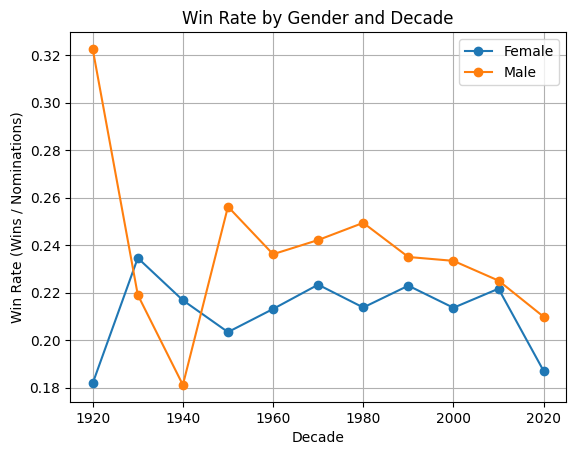

In [5]:
oscar_nominees['won'] = oscar_nominees['winner'] == True
win_rate = oscar_nominees.groupby(['decade', 'gender'])['won'].mean().unstack()

plt.figure()
for col in win_rate.columns:
    plt.plot(win_rate.index, win_rate[col], marker='o', label=col)
plt.title("Win Rate by Gender and Decade")
plt.xlabel("Decade")
plt.ylabel("Win Rate (Wins / Nominations)")
plt.legend()
plt.grid(True)
plt.show()

## Female Representation by Decade Across Non-Acting Categories

This section plots the proportion of female nominees by decade separately for directing,
cinematography, film editing, best picture, both writing categories, and all other awards
grouped together (excluding acting categories since those are gender-defined by design).

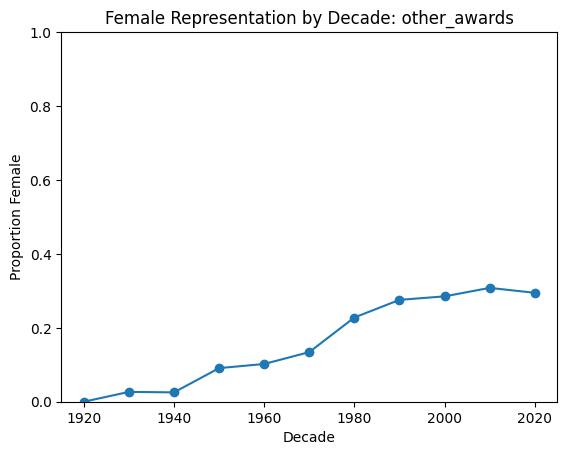

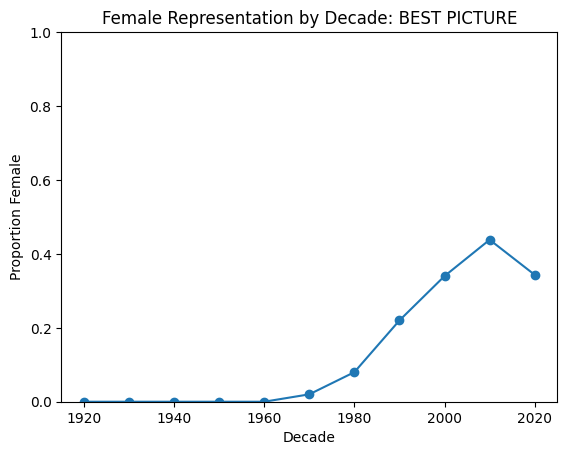

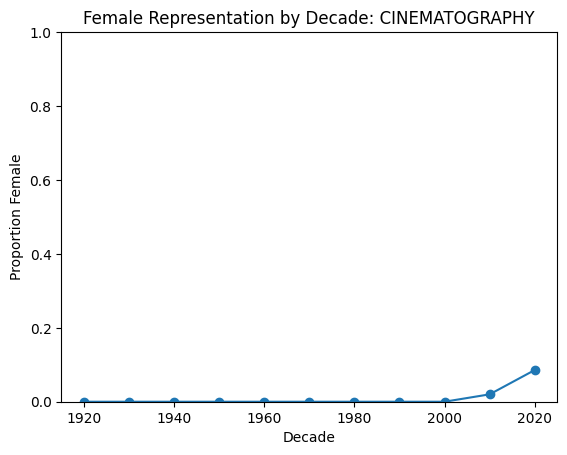

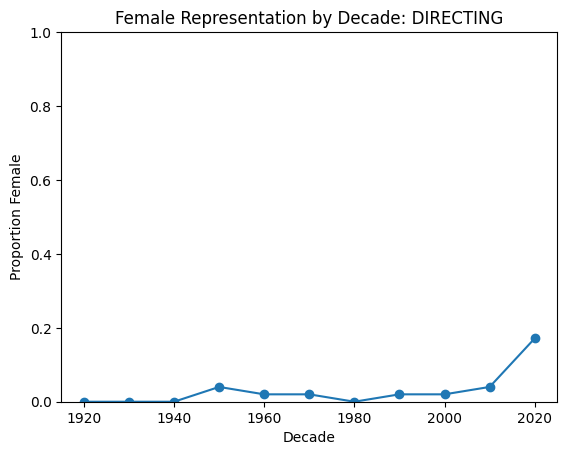

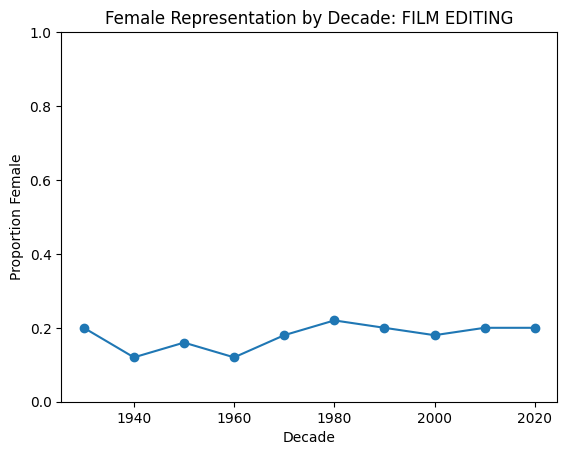

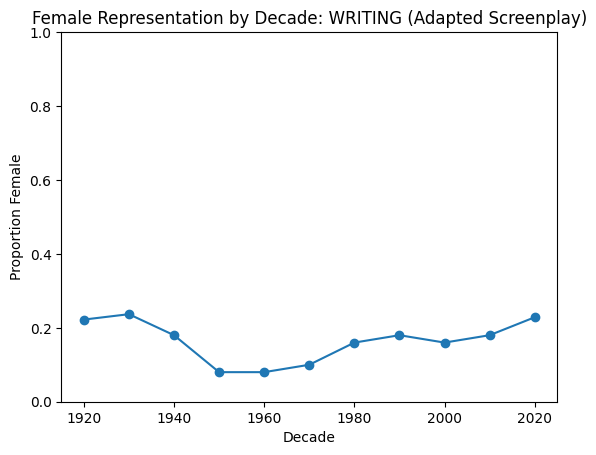

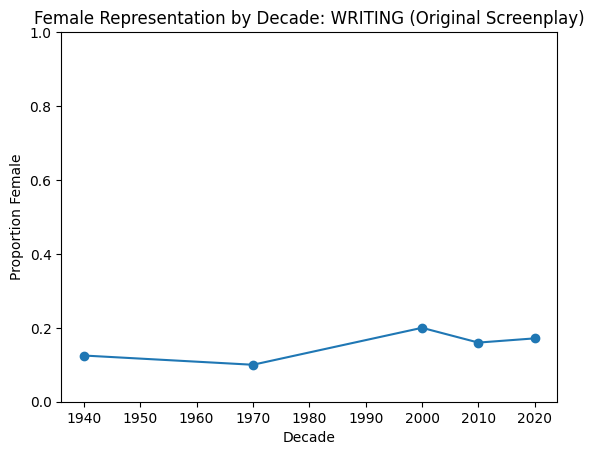

In [6]:
focus_categories = [
    'DIRECTING',
    'CINEMATOGRAPHY',
    'FILM EDITING',
    'BEST PICTURE',
    'WRITING (Adapted Screenplay)',
    'WRITING (Original Screenplay)'
]

non_acting = oscar_nominees[
    ~oscar_nominees['Category'].str.contains('ACTOR|ACTRESS', case=False, na=False)
].copy()

non_acting['decade'] = (non_acting['year_ceremony'] // 10) * 10

non_acting['Category_grouped'] = non_acting['Category'].apply(
    lambda x: x if x in focus_categories else 'other_awards'
)

non_acting['is_female'] = non_acting['gender'] == 'Female'

categories = non_acting['Category_grouped'].unique()

for cat in categories:
    cat_data = non_acting[non_acting['Category_grouped'] == cat]
    
    trend = cat_data.groupby('decade')['is_female'].mean()
    
    plt.figure()
    plt.plot(trend.index, trend.values, marker='o')
    
    plt.title(f"Female Representation by Decade: {cat}")
    plt.xlabel("Decade")
    plt.ylabel("Proportion Female")
    plt.ylim(0, 1)
    
    plt.show()

## Race Representation of Nominees Over Time

This graph plots the raw annual nomination counts by race.

<Figure size 640x480 with 0 Axes>

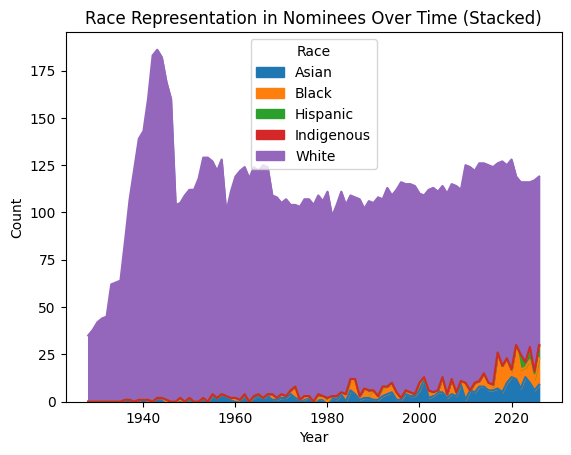

In [7]:
race_year = oscar_nominees.groupby(['year_ceremony', 'Race']).size().unstack(fill_value=0)

plt.figure()
race_year.plot.area()
plt.title("Race Representation in Nominees Over Time (Stacked)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### White Nominee & Winner Proportion by Decade

This plot tracks the proportion of white nominees and winners across decades.
By comparing the two lines, we can assess whether white representation differs
between nomination and winning stages of the Oscars.

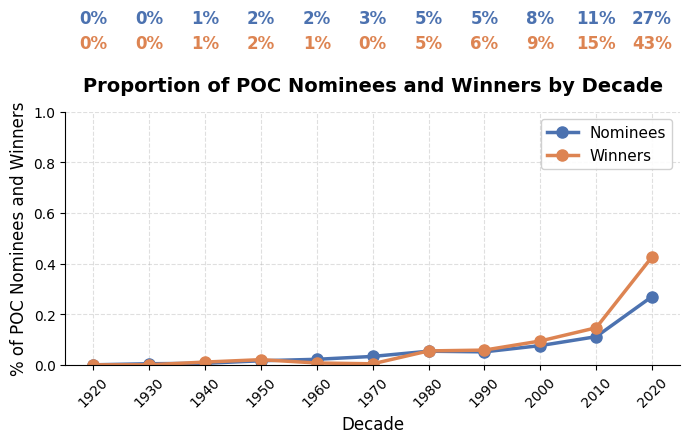

In [27]:
oscar_nominees['is_white'] = oscar_nominees['Race'] == 'White'
oscar_nominees['is_not_white'] = oscar_nominees['Race'] != 'White'

winners = oscar_nominees[oscar_nominees['winner'] == True]

nominees_decade_race = oscar_nominees.groupby('decade')['is_not_white'].mean()
winners_decade_race = winners.groupby('decade')['is_not_white'].mean()

race_prop_plot = nominees_decade_race.to_frame(name='Nominees')
race_prop_plot['Winners'] = winners_decade_race

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(race_prop_plot.index, race_prop_plot['Nominees'], marker='o',
        linewidth=2.5, markersize=8, label='Nominees', color='#4C72B0')
ax.plot(race_prop_plot.index, race_prop_plot['Winners'], marker='o',
        linewidth=2.5, markersize=8, label='Winners', color='#DD8452')

for decade, row in race_prop_plot.iterrows():
    ax.text(decade, 1.35, f"{row['Nominees']:.0%}",
            ha='center', fontsize=12, color='#4C72B0', fontweight='bold')
    ax.text(decade, 1.25, f"{row['Winners']:.0%}",
            ha='center', fontsize=12, color='#DD8452', fontweight='bold')

ax.set_ylim(0, 1.5)

ax.set_title("Proportion of POC Nominees and Winners by Decade",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Decade", fontsize=12)
ax.set_ylabel("% of POC Nominees and Winners", fontsize=12)
ax.set_ylim(0, 1)
ax.set_xticks(race_prop_plot.index)
ax.set_xticklabels(race_prop_plot.index, rotation=45)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Win Rate by Race and Decade

This plot shows the share of nominations that converted into wins for each racial group
across decades, revealing whether any group faces a systematic gap between being nominated
and actually winning.

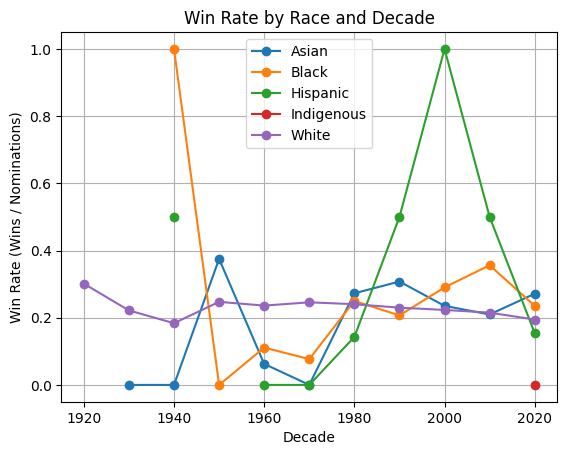

In [45]:
win_rate_race = oscar_nominees.groupby(['decade', 'Race'])['won'].mean().unstack()

plt.figure()
for col in win_rate_race.columns:
    plt.plot(win_rate_race.index, win_rate_race[col], marker='o', label=col)
plt.title("Win Rate by Race and Decade")
plt.xlabel("Decade")
plt.ylabel("Win Rate (Wins / Nominations)")
plt.legend()
plt.grid(True)
plt.show()

## Race Proportions by Category and Decade

This grid of plots breaks down racial composition of nominees by decade for each category
separately, including all four acting categories, six key technical and creative categories,
and a catch-all for remaining awards. This allows us to compare where racial diversity has
and hasn't improved across different parts of the Oscars.

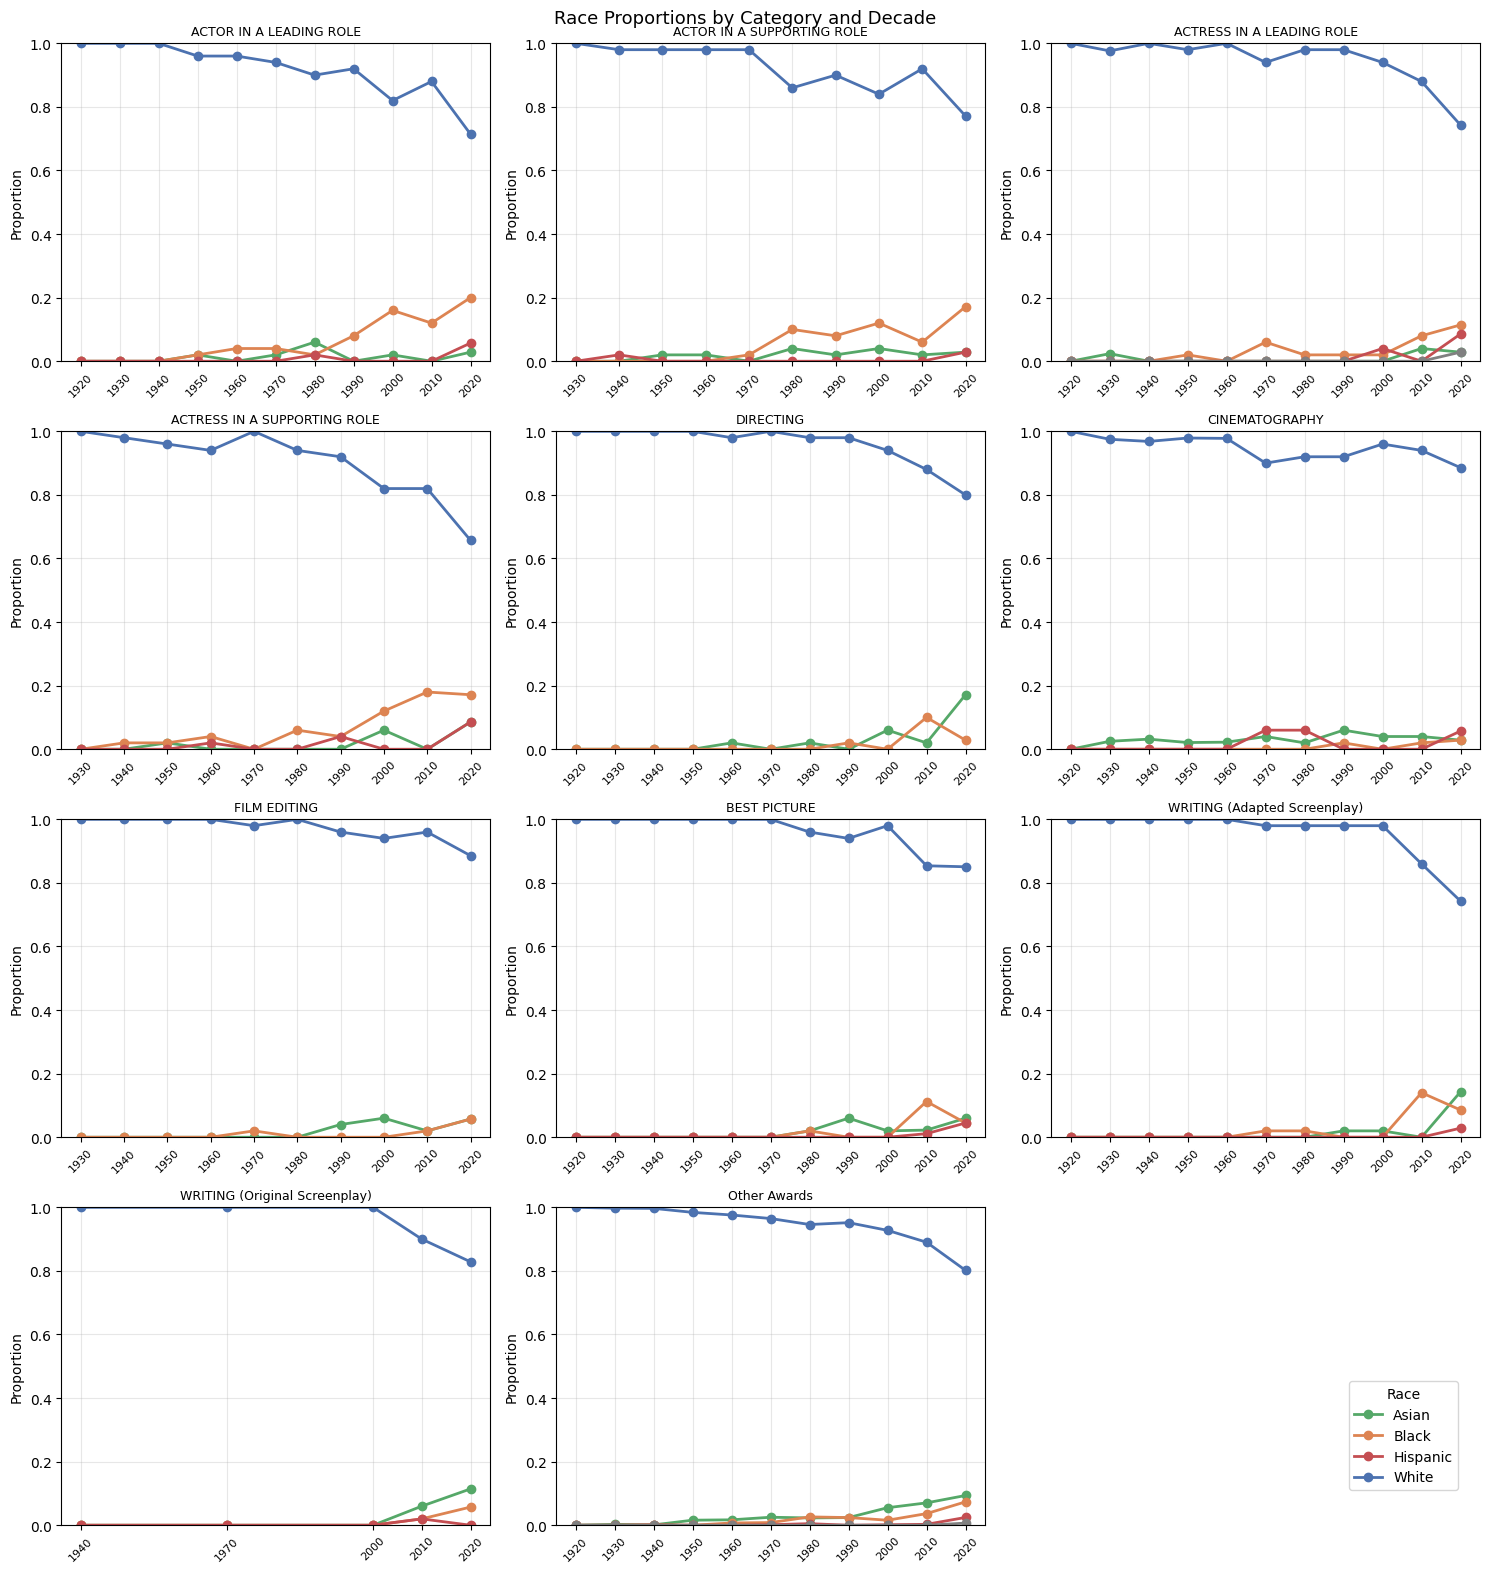

In [46]:
acting = ['ACTOR IN A LEADING ROLE', 'ACTOR IN A SUPPORTING ROLE',
          'ACTRESS IN A LEADING ROLE', 'ACTRESS IN A SUPPORTING ROLE']
focus  = ['DIRECTING', 'CINEMATOGRAPHY', 'FILM EDITING', 'BEST PICTURE',
          'WRITING (Adapted Screenplay)', 'WRITING (Original Screenplay)']

def group_category(cat):
    if cat in acting: return cat
    if cat in focus:  return cat
    return 'Other Awards'

oscar_nominees['Category_grouped'] = oscar_nominees['Category'].apply(group_category)
groups = acting + focus + ['Other Awards']

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, cat in enumerate(groups):
    ax = axes[i]
    data = oscar_nominees[oscar_nominees['Category_grouped'] == cat]
    props = (
        data.groupby(['decade', 'Race']).size()
        .unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    for race in props.columns:
        ax.plot(props.index, props[race], marker='o',
                label=race, color=race_colors.get(race, 'gray'), linewidth=2)
    ax.set_title(cat, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)
    ax.set_xticks(props.index)
    ax.set_xticklabels(props.index, rotation=45, fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Race", loc='lower right', bbox_to_anchor=(0.98, 0.05))
plt.suptitle("Race Proportions by Category and Decade", fontsize=13)
plt.tight_layout()
plt.show()

In [29]:
C = {
    'pre':  '#4C72B0',   # blue for pre-OscarsSoWhite decades
    'post': '#DD8452',   # orange for post-OscarsSoWhite decades
    'poc':  '#55A868',   # green for POC line/fill
    'dark': '#2d2d2d',   # dark gray for main line
}

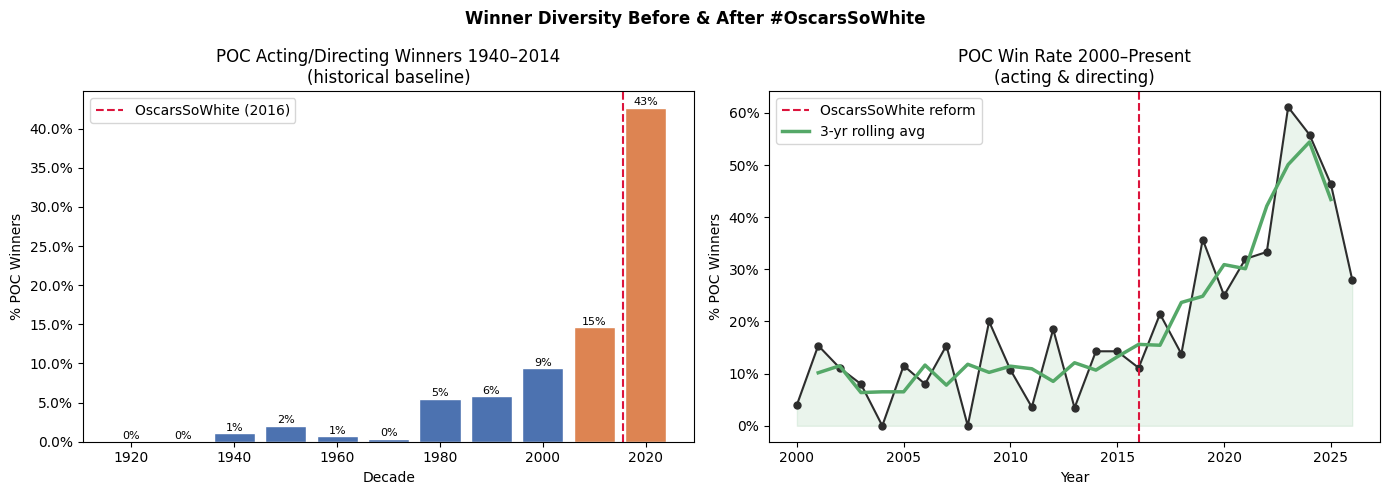

In [32]:
# -- 4d. Visualization: Nomination diversity trend ----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Winner Diversity Before & After #OscarsSoWhite', fontweight='bold')

# Filter for winners only
oscar_winners = oscar_nominees[oscar_nominees['winner'] == True].copy()
oscar_winners['decade'] = (oscar_winners['year_ceremony'] // 10) * 10
oscar_winners['is_poc'] = oscar_winners['Race'] != 'White'

# Left: decade bars (historical baseline)
ax = axes[0]
hist = oscar_winners.groupby('decade')['is_poc'].mean().reset_index()
hist.columns = ['decade', 'poc_pct']
hist['decade'] = hist['decade'].astype(int)

colors = [C['post'] if d >= 2010 else C['pre'] for d in hist['decade']]
bars = ax.bar(hist['decade'], hist['poc_pct'] * 100, color=colors, width=8, edgecolor='white')
ax.axvline(2015.5, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Decade')
ax.set_ylabel('% POC Winners')
ax.set_title('POC Acting/Directing Winners 1940–2014\n(historical baseline)')
ax.legend()
for bar, val in zip(bars, hist['poc_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0%}', ha='center', fontsize=8)

# Right: year-by-year
ax = axes[1]
diversity_by_year = oscar_winners.groupby('year_ceremony')['is_poc'].mean().reset_index()
diversity_by_year.columns = ['Year', 'poc_pct']
diversity_by_year['Year'] = diversity_by_year['Year'].astype(int)

modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
ax.plot(modern['Year'], modern['poc_pct'] * 100,
        color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(modern['Year'], modern['poc_pct'] * 100, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')
rolling = modern['poc_pct'].rolling(3, center=True).mean() * 100
ax.plot(modern['Year'], rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year')
ax.set_ylabel('% POC Winners')
ax.set_title('POC Win Rate 2000–Present\n(acting & directing)')
ax.legend()

plt.tight_layout()
plt.show()

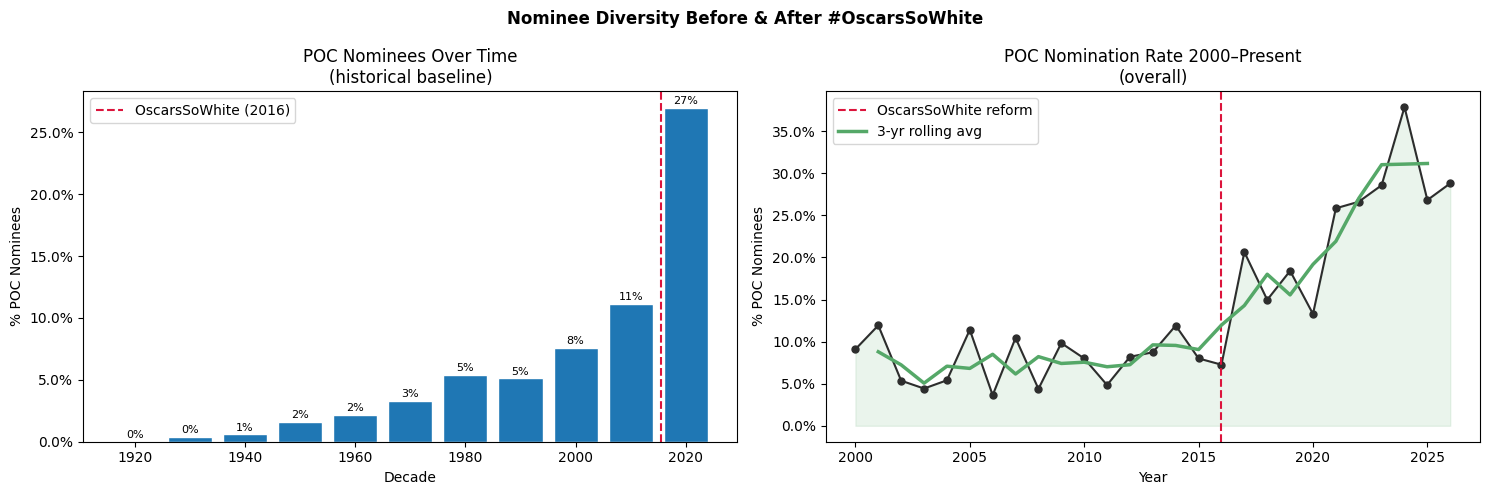

Saved to data_story_outputs/fig1_nominee_diversity.png


In [53]:
# -- Nomination diversity trend (NOMINEES) ----------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Nominee Diversity Before & After #OscarsSoWhite', fontweight='bold')

oscar_nominees['decade'] = (oscar_nominees['year_ceremony'] // 10) * 10
oscar_nominees['is_poc'] = oscar_nominees['Race'] != 'White'

# Left: decade bars
ax = axes[0]
hist = oscar_nominees.groupby('decade')['is_poc'].mean().reset_index()
hist.columns = ['decade', 'poc_pct']
hist['decade'] = hist['decade'].astype(int)

bars = ax.bar(hist['decade'], hist['poc_pct'] * 100, width=8, edgecolor='white')
ax.axvline(2015.5, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Decade')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nominees Over Time\n(historical baseline)')
ax.legend()
for bar, val in zip(bars, hist['poc_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0%}', ha='center', fontsize=8)

# Right: year-by-year
ax = axes[1]
diversity_by_year = oscar_nominees.groupby('year_ceremony')['is_poc'].mean().reset_index()
diversity_by_year.columns = ['Year', 'poc_pct']
diversity_by_year['Year'] = diversity_by_year['Year'].astype(int)

modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
ax.plot(modern['Year'], modern['poc_pct'] * 100,
        color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(modern['Year'], modern['poc_pct'] * 100, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')
rolling = modern['poc_pct'].rolling(3, center=True).mean() * 100
ax.plot(modern['Year'], rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(overall)')
ax.legend()

plt.tight_layout()
plt.show()
print('Saved to data_story_outputs/fig1_nominee_diversity.png')

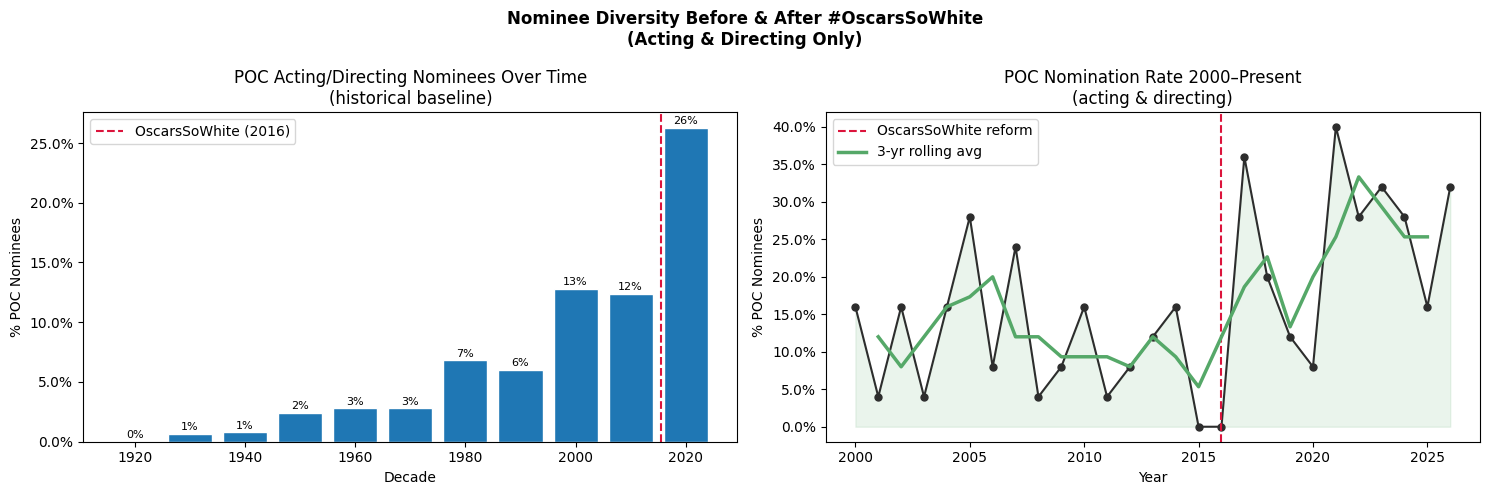

In [54]:
acting_directing = [
    'ACTOR IN A LEADING ROLE', 'ACTOR IN A SUPPORTING ROLE',
    'ACTRESS IN A LEADING ROLE', 'ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING'
]

ad_nominees = oscar_nominees[oscar_nominees['Category'].isin(acting_directing)].copy()
ad_nominees['decade'] = (ad_nominees['year_ceremony'] // 10) * 10
ad_nominees['is_poc'] = ad_nominees['Race'] != 'White'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Nominee Diversity Before & After #OscarsSoWhite\n(Acting & Directing Only)', fontweight='bold')

# Left: decade bars
ax = axes[0]
hist = ad_nominees.groupby('decade')['is_poc'].mean().reset_index()
hist.columns = ['decade', 'poc_pct']
hist['decade'] = hist['decade'].astype(int)

bars = ax.bar(hist['decade'], hist['poc_pct'] * 100, width=8, edgecolor='white')
ax.axvline(2015.5, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Decade')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Acting/Directing Nominees Over Time\n(historical baseline)')
ax.legend()
for bar, val in zip(bars, hist['poc_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0%}', ha='center', fontsize=8)

# Right: year-by-year
ax = axes[1]
diversity_by_year = ad_nominees.groupby('year_ceremony')['is_poc'].mean().reset_index()
diversity_by_year.columns = ['Year', 'poc_pct']
diversity_by_year['Year'] = diversity_by_year['Year'].astype(int)

modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
ax.plot(modern['Year'], modern['poc_pct'] * 100,
        color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(modern['Year'], modern['poc_pct'] * 100, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')
rolling = modern['poc_pct'].rolling(3, center=True).mean() * 100
ax.plot(modern['Year'], rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(acting & directing)')
ax.legend()

plt.tight_layout()
plt.show()